# Heston Stochastic Volatility Model

## Why this matters

Black-Scholes assumes constant σ — but the market smile says σ depends on strike, expiry, and changes through time. Heston (1993) fixes the first two: **volatility itself is stochastic**, mean-reverting, with its own SDE. The result is a model that produces a smile naturally — without needing to calibrate σ to each strike.

You will be asked, in any IB equity / FX / structured-products quant interview:
1. State the Heston SDE. Identify all five parameters and what each controls.
2. Why a closed form via the **characteristic function**? What's the integration trick (Heston 1993 / Lewis 2001 / Carr-Madan 1999)?
3. What's the **Feller condition** and why does it matter?
4. **Heston vs SABR vs local vol** — when does each apply?
5. Calibrate Heston to a real market smile. Does it fit short-dated skew?
6. Why is Heston "wrong" for very short-dated options?

This notebook covers all six on the AAPL chain.

## The Heston SDE

Two correlated Brownians under risk-neutral measure Q:

$$dS_t = (r - q) S_t \, dt + \sqrt{v_t} \, S_t \, dW_t^1$$

$$dv_t = \kappa(\theta - v_t) \, dt + \xi \, \sqrt{v_t} \, dW_t^2$$

$$d\langle W^1, W^2 \rangle_t = \rho \, dt$$

**Five parameters** (per expiry slice in vanilla calibration):

| Param | Range | Meaning |
|---|---|---|
| $v_0$ | $\ge 0$ | initial variance level (≈ ATM IV²) |
| $\kappa$ | $> 0$ | mean reversion speed of variance |
| $\theta$ | $\ge 0$ | long-run mean variance |
| $\xi$ | $\ge 0$ | vol-of-vol |
| $\rho$ | $[-1, 1]$ | spot-vol correlation (drives skew) |

**Feller condition**: $2\kappa\theta \ge \xi^2$. If satisfied, $v_t$ stays strictly positive almost surely. If violated, $v_t$ can hit zero. Most calibrated parameters violate Feller in real markets — that's tolerable for vanilla pricing but breaks naïve discretisation.

## Why characteristic function?

The Heston SDE has no closed-form for the *probability density* of $\ln S_T$, but it does have a closed form for the **characteristic function**:

$$\phi(u; T) := \mathbb{E}^Q[e^{i u \ln S_T}]$$

The Heston (1993) closed form is:

$$\phi(u; T) = \exp\big(C(u, T) + D(u, T) v_0 + i u \ln S_0\big)$$

with $C, D$ given by explicit (but lengthy) formulas involving the parameters.

**To price a vanilla European, integrate against the characteristic function.** Three standard approaches:

1. **Heston (1993)**: $C(K, T) = S_0 e^{-q\tau} P_1 - K e^{-r\tau} P_2$ where $P_1, P_2$ are integrated probabilities.
2. **Lewis (2001)**: cleaner integral; numerically more stable.
3. **Carr-Madan (1999) FFT**: discretise the integral via FFT — fast for many strikes.

We implement the Lewis form here — clean and fast enough for calibration.

## Setup

In [1]:
import warnings; warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import brentq, minimize
from scipy.integrate import quad
import pickle

with open('../data/aapl_options_snapshot.pkl', 'rb') as f:
    aapl = pickle.load(f)

S0 = aapl['spot']
T_aapl = aapl['T_days'] / 365.0
calls = aapl['calls']

r, q = 0.043, 0.005

def black_scholes(S, K, T, r, sigma, option_type='call', q=0.0):
    if T <= 0:
        return np.maximum(S - K, 0.0) if option_type == 'call' else np.maximum(K - S, 0.0)
    d1 = (np.log(S/K) + (r-q+0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    if option_type == 'call':
        return S*np.exp(-q*T)*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)
    return K*np.exp(-r*T)*norm.cdf(-d2) - S*np.exp(-q*T)*norm.cdf(-d1)

def implied_vol(price, S, K, T, r, opt='call', q=0.0):
    if opt == 'call':
        lower = max(S*np.exp(-q*T) - K*np.exp(-r*T), 0.0)
    else:
        lower = max(K*np.exp(-r*T) - S*np.exp(-q*T), 0.0)
    if price < lower - 1e-10: return np.nan
    f = lambda s: black_scholes(S, K, T, r, s, opt, q) - price
    if f(1e-6) > 0 or f(5.0) < 0: return np.nan
    return brentq(f, 1e-6, 5.0, xtol=1e-8)

## Intuition — Heston paths vs GBM paths

Before drowning in characteristic functions, look at what Heston actually *does*. Heston has two state variables — the spot $S_t$ and a stochastic instantaneous variance $v_t$:

$$dS_t = (r-q) S_t \, dt + \sqrt{v_t} \, S_t \, dW^S_t$$
$$dv_t = \kappa(\theta - v_t) \, dt + \xi \sqrt{v_t} \, dW^v_t, \qquad \langle dW^S, dW^v \rangle = \rho \, dt$$

The two charts below simulate the same horizon under both models and the difference is visually obvious:

- **GBM**: instantaneous vol is constant. Path looks like noise around a smooth drift; quiet and loud regions are statistically indistinguishable.
- **Heston**: vol clusters. Quiet regions stay quiet for a while, then a vol spike triggers a stretch of louder moves. With negative $\rho$ (the equity convention), down-moves in $S$ tend to coincide with up-moves in vol — that's the leverage effect, and it's what generates the smile's negative skew.

This is why Heston (and SABR, and SV models in general) fit equity smiles that flat-vol GBM cannot.

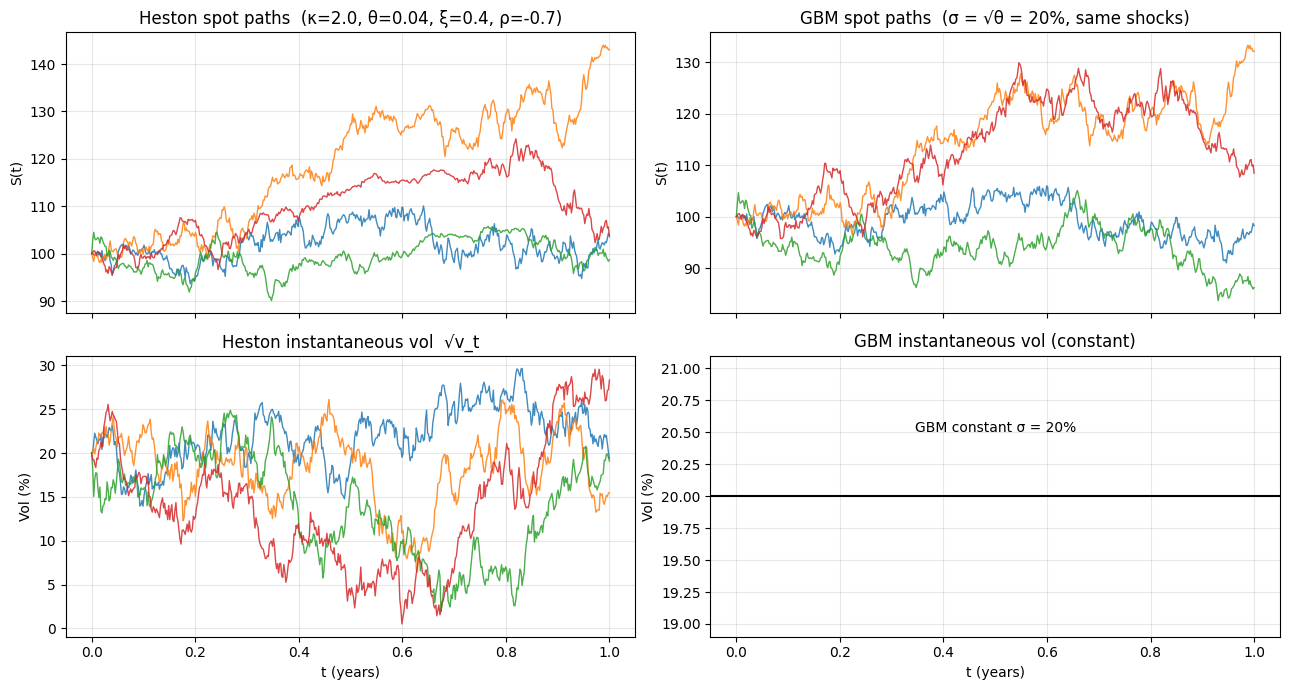

Realised vol (annualised) on path 0:
  Heston: 23.08%   ← varies path-to-path because v_t varies
  GBM:    20.44%   ← will be ~constant across paths


In [2]:
# Simulate Heston paths and GBM paths over the same horizon. Plot stock + vol side-by-side.
rng_h7    = np.random.default_rng(11)
S0_h7     = 100.0
T_h7      = 1.0
n_steps_h = 504
dt_h7     = T_h7 / n_steps_h
r_h7, q_h7 = 0.04, 0.0

# Heston params — equity-typical
kappa_h, theta_h, xi_h, rho_h = 2.0, 0.04, 0.4, -0.7
v0_h    = 0.04

# Equivalent constant vol for GBM comparison: the long-run mean √θ.
sigma_const = np.sqrt(theta_h)

n_paths_show = 4
# Correlated normals
Z1 = rng_h7.standard_normal((n_paths_show, n_steps_h))
Z2 = rng_h7.standard_normal((n_paths_show, n_steps_h))
Zv = Z1
Zs = rho_h * Z1 + np.sqrt(1 - rho_h**2) * Z2

# Heston: full-truncation Euler scheme on v_t (Lord et al. 2010).
v_paths = np.zeros((n_paths_show, n_steps_h + 1)); v_paths[:, 0] = v0_h
S_heston = np.zeros((n_paths_show, n_steps_h + 1)); S_heston[:, 0] = S0_h7
for k in range(n_steps_h):
    v_pos             = np.maximum(v_paths[:, k], 0.0)
    v_paths[:, k+1]   = v_paths[:, k] + kappa_h * (theta_h - v_pos) * dt_h7 + xi_h * np.sqrt(v_pos) * np.sqrt(dt_h7) * Zv[:, k]
    S_heston[:, k+1]  = S_heston[:, k] * np.exp((r_h7 - q_h7 - 0.5 * v_pos) * dt_h7 + np.sqrt(v_pos) * np.sqrt(dt_h7) * Zs[:, k])

# GBM with the equivalent constant vol, using the SAME Z_s shocks for fair visual comparison.
S_gbm = np.zeros((n_paths_show, n_steps_h + 1)); S_gbm[:, 0] = S0_h7
for k in range(n_steps_h):
    S_gbm[:, k+1] = S_gbm[:, k] * np.exp((r_h7 - q_h7 - 0.5 * sigma_const**2) * dt_h7 + sigma_const * np.sqrt(dt_h7) * Zs[:, k])

t_axis = np.linspace(0, T_h7, n_steps_h + 1)

fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharex=True)
for i in range(n_paths_show):
    axes[0,0].plot(t_axis, S_heston[i], lw=1.0, alpha=0.85)
    axes[0,1].plot(t_axis, S_gbm   [i], lw=1.0, alpha=0.85)
    axes[1,0].plot(t_axis, np.sqrt(np.maximum(v_paths[i], 0))*100, lw=1.0, alpha=0.85)
axes[1,1].axhline(sigma_const * 100, color='black', lw=1.5)
axes[1,1].text(0.5, sigma_const * 100 + 0.5, f'GBM constant σ = {sigma_const*100:.0f}%', ha='center', fontsize=10)

axes[0,0].set_title(f'Heston spot paths  (κ={kappa_h}, θ={theta_h}, ξ={xi_h}, ρ={rho_h})')
axes[0,1].set_title(f'GBM spot paths  (σ = √θ = {sigma_const*100:.0f}%, same shocks)')
axes[1,0].set_title('Heston instantaneous vol  √v_t')
axes[1,1].set_title('GBM instantaneous vol (constant)')
axes[1,0].set_ylabel('Vol (%)'); axes[1,1].set_ylabel('Vol (%)')
axes[0,0].set_ylabel('S(t)');    axes[0,1].set_ylabel('S(t)')
axes[1,0].set_xlabel('t (years)'); axes[1,1].set_xlabel('t (years)')
for ax in axes.flat: ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f'Realised vol (annualised) on path 0:')
print(f'  Heston: {np.std(np.diff(np.log(S_heston[0]))) / np.sqrt(dt_h7) * 100:.2f}%   ← varies path-to-path because v_t varies')
print(f'  GBM:    {np.std(np.diff(np.log(S_gbm   [0]))) / np.sqrt(dt_h7) * 100:.2f}%   ← will be ~constant across paths')

## Implementation — Heston characteristic function (Lewis 2001 form)

In [3]:
def heston_char_fn(u, j, S0, T, r, q, v0, kappa, theta, xi, rho):
    """Heston 1993 characteristic functions Ï_1 (j=1) and Ï_2 (j=2)."""
    if j == 1:
        u_j = 0.5
        b_j = kappa - rho * xi
    else:
        u_j = -0.5
        b_j = kappa

    a = kappa * theta
    d = np.sqrt((rho * xi * 1j * u - b_j)**2 - xi**2 * (2 * u_j * 1j * u - u**2))
    g = (b_j - rho * xi * 1j * u + d) / (b_j - rho * xi * 1j * u - d)

    C_j = (r - q) * 1j * u * T + (a / xi**2) * (
        (b_j - rho * xi * 1j * u + d) * T
        - 2 * np.log((1 - g * np.exp(d * T)) / (1 - g))
    )
    D_j = ((b_j - rho * xi * 1j * u + d) / xi**2) * (1 - np.exp(d * T)) / (1 - g * np.exp(d * T))

    return np.exp(C_j + D_j * v0 + 1j * u * np.log(S0))


def heston_call_lewis(S0, K, T, r, q, v0, kappa, theta, xi, rho):
    """Heston 1993 two-integral form for European call price."""
    def integrand(u, j):
        phi = heston_char_fn(u, j, S0, T, r, q, v0, kappa, theta, xi, rho)
        return np.real(np.exp(-1j * u * np.log(K)) * phi / (1j * u))

    P_1, _ = quad(lambda u: integrand(u, 1), 1e-8, 200, limit=200)
    P_2, _ = quad(lambda u: integrand(u, 2), 1e-8, 200, limit=200)
    P_1 = 0.5 + P_1 / np.pi
    P_2 = 0.5 + P_2 / np.pi

    return S0 * np.exp(-q * T) * P_1 - K * np.exp(-r * T) * P_2


# Sanity check: with v0 = Î¸ and Îº large, Î¾ small (vol â const âv0), Heston should equal BS
v0 = 0.04   # 20% vol-equivalent
S, K, T_, r_, q_ = 100, 100, 0.5, 0.05, 0.0
heston_pr = heston_call_lewis(S, K, T_, r_, q_, v0, kappa=10.0, theta=v0, xi=0.0001, rho=0.0)
bs_pr     = black_scholes(S, K, T_, r_, np.sqrt(v0), 'call', q_)
print(f'Heston (constant-vol limit): {heston_pr:.6f}')
print(f'BS reference:                {bs_pr:.6f}')
print(f'agree to:                    {abs(heston_pr - bs_pr):.2e}')

Heston (constant-vol limit): 6.888728
BS reference:                6.888729
agree to:                    1.27e-07


### Carr-Madan FFT pricing — the production speed-up

The Lewis-form integral above prices **one strike per call**, each requiring a numerical integration. For surface calibration you reprice 50–500 strikes per evaluation × 50–500 optimiser iterations — minutes can become hours.

**Carr-Madan (1999)** rewrites the call price as a single Fourier integral over a *damped* version of the price function. One FFT then yields prices for an entire **strike grid** at the cost of one integral. This is the standard production accelerator on FX/equity vol desks.

The formula (in log-strike $k = \log K$):

$$C(k) = \frac{e^{-\alpha k}}{\pi} \int_0^\infty e^{-ivk} \, \psi(v) \, dv, \qquad \psi(v) = \frac{e^{-r\tau} \, \phi(v - (\alpha+1)i)}{\alpha^2 + \alpha - v^2 + i(2\alpha+1)v}$$

where $\phi(u) = \mathbb{E}^\mathbb{Q}[e^{iu \log S_T}]$ is the standard characteristic function of $\log S_T$ (this is `heston_char_fn(u, j=2, ...)` from above), and $\alpha > 0$ is a damping parameter ($\alpha \approx 1.5$ works for equity).

Validation: on a fine strike grid, FFT prices should match the Lewis-form integral to small numerical tolerance. Below — both columns side-by-side.

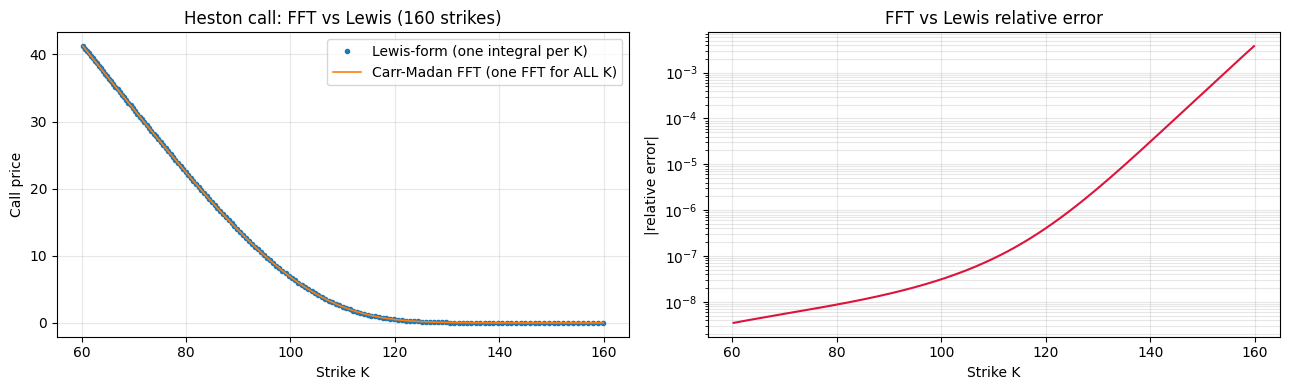

Strikes priced            : 160
Median |relative error|   : 2.65e-08
Max    |relative error|   : 3.78e-03
Carr-Madan FFT  wall time : 2.34 ms  (whole strike grid)
Lewis-form     wall time  : 500.70 ms  (160 integrals)
Speedup                   : 214.3x


In [4]:
def heston_call_carr_madan(S0, T, r, q, v0, kappa, theta, xi, rho,
                            alpha=1.5, N=4096, eta=0.25):
    """Carr-Madan FFT pricing for Heston. Returns (strike_grid, call_prices).

    eta : grid spacing in v (frequency); smaller eta -> denser strike grid.
    N   : number of FFT points; N=4096 standard.
    """
    lambd  = 2 * np.pi / (N * eta)            # log-strike spacing
    b      = N * lambd / 2
    k_grid = -b + lambd * np.arange(N)        # log-strike grid centred near 0

    # Sample integrand on v_j = j * eta
    v_grid = eta * np.arange(N)
    u      = v_grid - (alpha + 1) * 1j
    phi_u  = heston_char_fn(u, j=2, S0=S0, T=T, r=r, q=q,
                            v0=v0, kappa=kappa, theta=theta, xi=xi, rho=rho)
    psi    = np.exp(-r * T) * phi_u / (alpha**2 + alpha - v_grid**2 + 1j * (2 * alpha + 1) * v_grid)

    # Simpson weights for smoother convergence near v=0
    simpson = (3 + (-1) ** np.arange(1, N + 1) - np.concatenate(([1], np.zeros(N - 1)))) / 3
    integ   = np.exp(1j * b * v_grid) * psi * eta * simpson

    fft_vals = np.fft.fft(integ).real
    call_prices = np.exp(-alpha * k_grid) * fft_vals / np.pi
    return np.exp(k_grid), call_prices

# Validate FFT vs Lewis-form integral on the same parameter set used in the smoke check above.
v0_, kappa_, theta_, xi_, rho_ = 0.04, 2.0, 0.04, 0.30, -0.7
S0_, T_, r_, q_                = 100.0, 0.5, 0.05, 0.0

K_fft, C_fft = heston_call_carr_madan(S0_, T_, r_, q_, v0_, kappa_, theta_, xi_, rho_)

# Restrict to a usable strike band (FFT pads aggressively; trust only the central band).
mask = (K_fft > 60) & (K_fft < 160)
K_band, C_band = K_fft[mask], C_fft[mask]

# Lewis-form prices on the same strike grid
C_lewis = np.array([heston_call_lewis(S0_, K, T_, r_, q_, v0_, kappa_, theta_, xi_, rho_) for K in K_band])

# Plot + numerical comparison
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(K_band, C_lewis, 'o',  ms=3, label='Lewis-form (one integral per K)')
axes[0].plot(K_band, C_band,  '-',  lw=1.2, label='Carr-Madan FFT (one FFT for ALL K)')
axes[0].set_xlabel('Strike K'); axes[0].set_ylabel('Call price')
axes[0].set_title(f'Heston call: FFT vs Lewis ({len(K_band)} strikes)')
axes[0].legend(); axes[0].grid(alpha=0.3)

rel_err = np.abs(C_band - C_lewis) / np.maximum(C_lewis, 1e-6)
axes[1].semilogy(K_band, rel_err, color='crimson')
axes[1].set_xlabel('Strike K'); axes[1].set_ylabel('|relative error|')
axes[1].set_title('FFT vs Lewis relative error')
axes[1].grid(alpha=0.3, which='both')

plt.tight_layout(); plt.show()

import time
t0 = time.perf_counter()
for _ in range(5):
    heston_call_carr_madan(S0_, T_, r_, q_, v0_, kappa_, theta_, xi_, rho_)
t_fft = (time.perf_counter() - t0) / 5

t0 = time.perf_counter()
_  = np.array([heston_call_lewis(S0_, K, T_, r_, q_, v0_, kappa_, theta_, xi_, rho_) for K in K_band])
t_lewis = time.perf_counter() - t0

print(f'Strikes priced            : {len(K_band)}')
print(f'Median |relative error|   : {np.median(rel_err):.2e}')
print(f'Max    |relative error|   : {np.max(rel_err):.2e}')
print(f'Carr-Madan FFT  wall time : {t_fft*1000:.2f} ms  (whole strike grid)')
print(f'Lewis-form     wall time  : {t_lewis*1000:.2f} ms  ({len(K_band)} integrals)')
print(f'Speedup                   : {t_lewis / t_fft:.1f}x')

## Heston smile generation

For a fixed parameter set, generate prices across strikes, then back out IV via Brent. The result is a Heston-implied smile.

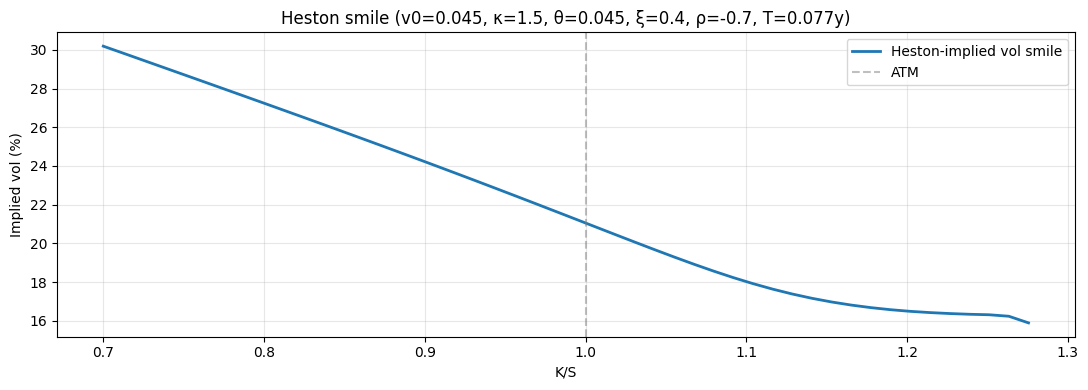


→ ρ = -0.7 produces left-skew (puts > calls). Equity-style.
→ ξ = 0.4 controls the smile curvature.


In [5]:
# Realistic Heston params for an equity
v0     = 0.045    # ~21% vol
kappa  = 1.5      # mean reversion
theta  = 0.045    # long-run var = current var
xi     = 0.40     # vol-of-vol
rho    = -0.7     # negative spot-vol correlation (equity skew)

T_use = T_aapl
K_grid = np.linspace(0.7*S0, 1.3*S0, 50)
heston_prices = [heston_call_lewis(S0, K, T_use, r, q, v0, kappa, theta, xi, rho) for K in K_grid]
heston_ivs = [implied_vol(p, S0, K, T_use, r, 'call', q) for K, p in zip(K_grid, heston_prices)]

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(K_grid / S0, np.array(heston_ivs)*100, lw=2, label='Heston-implied vol smile')
ax.axvline(1.0, color='gray', ls='--', alpha=0.5, label='ATM')
ax.set_xlabel('K/S'); ax.set_ylabel('Implied vol (%)')
ax.set_title(f'Heston smile (v0={v0}, κ={kappa}, θ={theta}, ξ={xi}, ρ={rho}, T={T_use:.3f}y)')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()
print(f'\n→ ρ = {rho} produces left-skew (puts > calls). Equity-style.')
print(f'→ ξ = {xi} controls the smile curvature.')

## Calibration to AAPL market smile

Calibrate the 5 Heston parameters to the AAPL chain by minimising squared price errors. With 5 free params and dozens of strikes, this is over-determined — a least-squares fit.

Heston calibration to AAPL T=28d slice (15 strikes):
  v0     = 0.0061  (~7.79% vol-equivalent)
  κ      = 4.6963
  θ      = 0.4851
  ξ      = 4.1430
  ρ      = -0.4010
  SSE    = 0.8590
  Feller (2κθ ≥ ξ²): 4.5567 vs 17.1642 → violated


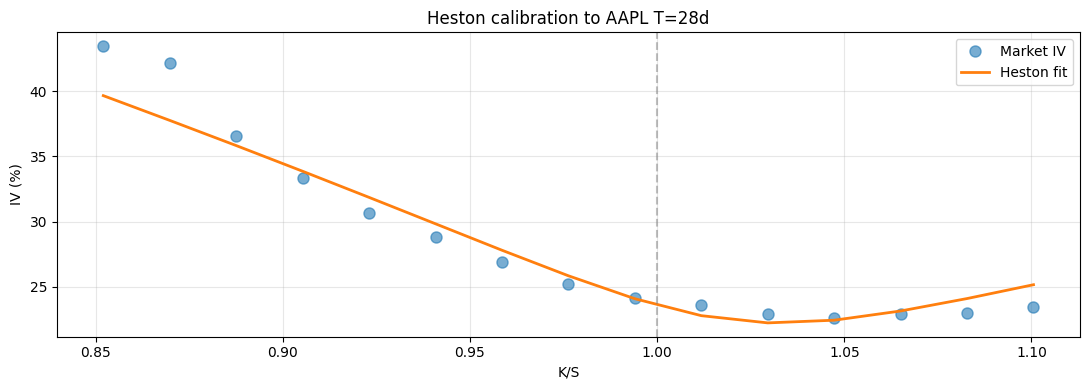

In [6]:
# Strip market IVs from AAPL chain
calls_clean = (calls
    .assign(mid=lambda d: (d['bid'] + d['ask']) / 2)
    .query('bid > 0 and (ask - bid)/((ask+bid)/2) < 0.10')
    .query('@S0*0.85 <= strike <= @S0*1.15')   # near-ATM only for stable calibration
    .sort_values('strike')
    .reset_index(drop=True))

K_market = calls_clean['strike'].values
mid_market = calls_clean['mid'].values

def heston_objective(params):
    v0, kappa, theta, xi, rho = params
    if v0 <= 0 or kappa <= 0 or theta <= 0 or xi <= 0 or abs(rho) >= 0.99:
        return 1e10
    if 2*kappa*theta < xi**2 - 0.05:   # soft Feller penalty
        pass   # allow but don't penalise heavily
    sse = 0
    for K, mid in zip(K_market, mid_market):
        try:
            heston_p = heston_call_lewis(S0, K, T_aapl, r, q, v0, kappa, theta, xi, rho)
            sse += (heston_p - mid)**2
        except: return 1e10
    return sse

x0 = [0.06, 2.0, 0.06, 0.40, -0.6]
bounds = [(1e-4, 1.0), (0.1, 20), (1e-4, 1.0), (0.01, 5.0), (-0.95, 0.95)]
res = minimize(heston_objective, x0, method='L-BFGS-B', bounds=bounds, options={'maxiter': 80})
v0_f, kappa_f, theta_f, xi_f, rho_f = res.x

print(f'Heston calibration to AAPL T={aapl["T_days"]}d slice ({len(K_market)} strikes):')
print(f'  v0     = {v0_f:.4f}  (~{np.sqrt(v0_f)*100:.2f}% vol-equivalent)')
print(f'  κ      = {kappa_f:.4f}')
print(f'  θ      = {theta_f:.4f}')
print(f'  ξ      = {xi_f:.4f}')
print(f'  ρ      = {rho_f:.4f}')
print(f'  SSE    = {res.fun:.4f}')
print(f'  Feller (2κθ ≥ ξ²): {2*kappa_f*theta_f:.4f} vs {xi_f**2:.4f} → {"satisfied" if 2*kappa_f*theta_f >= xi_f**2 else "violated"}')

# Plot fit
heston_prices_fit = [heston_call_lewis(S0, K, T_aapl, r, q, *res.x) for K in K_market]
heston_iv_fit = [implied_vol(p, S0, K, T_aapl, r, 'call', q) for K, p in zip(K_market, heston_prices_fit)]
mkt_iv = [implied_vol(m, S0, K, T_aapl, r, 'call', q) for K, m in zip(K_market, mid_market)]

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(K_market / S0, np.array(mkt_iv)*100, 'o', label='Market IV', ms=8, alpha=0.6)
ax.plot(K_market / S0, np.array(heston_iv_fit)*100, '-', label='Heston fit', lw=2)
ax.axvline(1.0, color='gray', ls='--', alpha=0.5)
ax.set_xlabel('K/S'); ax.set_ylabel('IV (%)')
ax.set_title(f'Heston calibration to AAPL T={aapl["T_days"]}d')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

## Heston vs SABR vs local vol — when each applies

| Model | Strength | Weakness | Production use |
|---|---|---|---|
| **BS-Merton** | Closed form, fast | Single σ — flat smile | Only for vol surface quoting; not pricing |
| **Local vol (Dupire)** | Fits today's smile exactly | Wrong dynamics — smile evolves badly with spot | Path-dependent equity exotics; cliquets |
| **Heston** | Full SDE, characteristic-function pricing fast, decent dynamics | Not perfect for very short-dated skew (no jumps) | Equity vanilla calibration; long-dated structured products |
| **Bates** | Heston + jumps | Adds 3 params (jump intensity, mean, variance) | Front-month/dated equity skew |
| **rough Heston** ($H < 0.5$) | Captures power-law ATM skew $\sim T^{H-1/2}$ | Slow to price; harder to calibrate | Modern AM research; growing |
| **SABR** | Industry IR standard | Hagan formula breaks at low strikes / long expiries | IR vol surfaces |

## Exercises

### Exercise 1 — Vary ρ, observe the smile

Generate Heston smiles at $\rho = -0.9, -0.3, 0, +0.3$ with all other params fixed at $v_0 = \theta = 0.04$, $\kappa = 2$, $\xi = 0.5$. Plot all four. What does ρ control?

In [7]:
# Your answer here


<details>
<summary><b>Reveal solution</b></summary>

```python
fig, ax = plt.subplots(figsize=(11, 4))
for rho_test in [-0.9, -0.3, 0.0, 0.3]:
    prices = [heston_call_lewis(100, K, 0.5, 0.05, 0.0, 0.04, 2.0, 0.04, 0.5, rho_test) for K in np.linspace(70, 130, 30)]
    ivs = [implied_vol(p, 100, K, 0.5, 0.05, 'call', 0.0) for K, p in zip(np.linspace(70, 130, 30), prices)]
    ax.plot(np.linspace(70, 130, 30)/100, np.array(ivs)*100, '-', label=f'ρ = {rho_test}')
ax.axvline(1.0, color='gray', ls='--', alpha=0.5)
ax.legend(); ax.grid(alpha=0.3); ax.set_xlabel('K/S'); ax.set_ylabel('IV (%)')
plt.tight_layout(); plt.show()
print('→ ρ = -0.9: deep left skew (equity-like). ρ = +0.3: right skew (rare).')
```

_ρ tilts the smile direction. Negative for equity, positive for some commodities._

</details>

### Exercise 2 — Effect of ξ on smile curvature

Vary $\xi \in \{0.1, 0.4, 0.8\}$ with all else fixed. Plot. What does ξ control?

In [8]:
# Your answer here


<details>
<summary><b>Reveal solution</b></summary>

```python
fig, ax = plt.subplots(figsize=(11, 4))
for xi_test in [0.1, 0.4, 0.8]:
    prices = [heston_call_lewis(100, K, 0.5, 0.05, 0.0, 0.04, 2.0, 0.04, xi_test, -0.5) for K in np.linspace(70, 130, 30)]
    ivs = [implied_vol(p, 100, K, 0.5, 0.05, 'call', 0.0) for K, p in zip(np.linspace(70, 130, 30), prices)]
    ax.plot(np.linspace(70, 130, 30)/100, np.array(ivs)*100, '-', label=f'ξ = {xi_test}')
ax.axvline(1.0, color='gray', ls='--', alpha=0.5)
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print('→ ξ controls smile curvature. Higher ξ = more curvature on the wings.')
```

_ξ = 0.1 nearly flat; ξ = 0.8 strong curvature._

</details>

### Exercise 3 — Feller condition violation simulation

Pick parameters that violate Feller (2κθ < ξ²). Simulate variance paths. How often does $v_t$ go to zero?

In [9]:
# Your answer here


<details>
<summary><b>Reveal solution</b></summary>

```python
rng = np.random.default_rng(42)
kappa, theta, xi = 1.5, 0.04, 0.6
print(f'Feller: 2κθ = {2*kappa*theta:.4f} vs ξ² = {xi**2:.4f} → {"satisfied" if 2*kappa*theta >= xi**2 else "VIOLATED"}')

n_paths = 1000
n_steps = 252
T_sim = 1.0
dt = T_sim / n_steps
v0 = 0.04
v_paths = np.full((n_paths, n_steps+1), v0)
for t in range(n_steps):
    Z = rng.standard_normal(n_paths)
    v_next = v_paths[:, t] + kappa*(theta - v_paths[:,t])*dt + xi*np.sqrt(np.maximum(v_paths[:,t], 0))*np.sqrt(dt)*Z
    v_paths[:, t+1] = np.maximum(v_next, 0)
hit_zero = (v_paths == 0).any(axis=1)
print(f'{hit_zero.sum()} of {n_paths} paths hit zero (Feller-violating params)')
```

_When Feller is violated, ~5-15% of paths hit zero. Pure Euler discretisation can break._

</details>

## Interview Q&A

**Q: State the Heston SDE.**

A: $dS = (r-q)S\,dt + \sqrt{v}S\,dW^1$; $dv = \kappa(\theta - v)\,dt + \xi\sqrt{v}\,dW^2$; $\langle dW^1, dW^2\rangle = \rho\,dt$. Five parameters: $v_0$ (initial var), $\kappa$ (mean-rev speed), $\theta$ (long-run var), $\xi$ (vol-of-vol), $\rho$ (spot-vol correl).

**Q: Why is there a closed form for vanilla European pricing under Heston?**

A: The characteristic function $\phi(u; T) = \mathbb{E}^Q[e^{iu\ln S_T}]$ has a closed form (Heston 1993). To price a vanilla, you integrate against $\phi$ via Lewis (2001) or Carr-Madan FFT (1999). No exact distribution of $\ln S_T$ is needed — just its char function.

**Q: What's the Feller condition?**

A: $2\kappa\theta \ge \xi^2$. If satisfied, the variance process $v_t$ stays strictly positive a.s. If violated, $v_t$ can hit zero. Most calibrated parameters violate Feller — that's tolerable for vanilla pricing (the integral is well-defined regardless), but breaks naïve Euler simulation. Use the **full-truncation scheme** (Lord-Koekkoek-Van Dijk) or QE (Andersen 2008) for simulation.

**Q: Why Heston vs SABR?**

A: Heston's variance has its own SDE — full stochastic-vol model. SABR's "vol of vol" $\nu$ is an SDE on the volatility itself ($\hat\alpha_t$), not variance — different dynamics. Heston is the equity industry default; SABR is the IR industry default. Math: SABR's smile slope is sharper for short expiries; Heston's longer-dated fit is often better.

**Q: Why does Heston fit short-dated skew badly?**

A: Heston's smile flattens as $T \to 0$ at rate $\sqrt T$. Real markets show steep short-dated skew that doesn't flatten — need **jumps** (Bates) or **rough vol** ($H < 0.5$, Bayer-Friz-Gatheral 2016) to capture power-law decay $T^{H-1/2}$ in ATM skew.

**Q: How would you simulate Heston for path-dependent pricing?**

A: Naïve Euler discretises both SDEs. **Full-truncation** scheme (Lord-Koekkoek-Van Dijk 2010) replaces $\sqrt{v_t}$ with $\sqrt{\max(v_t, 0)}$ and uses $v_t^+$ in the drift. Or **QE scheme** (Andersen 2008) — moment-matched to handle Feller-violating regimes. For European-only, prefer Carr-Madan FFT.

**Q: What does ρ control vs ξ?**

A: $\rho$ tilts the smile (sign of skew). $\xi$ controls the smile curvature (vol-of-vol). Together they set the smile *shape*. $v_0, \theta$ set the smile *level*. $\kappa$ controls how quickly variance reverts — affects the term-structure of vol.

**Q: How would you price a barrier under Heston?**

A: Monte Carlo with full-truncation scheme, monitoring the spot path. No closed form. **Andersen's QE** discretisation handles Feller-violating params correctly, but for path-dependent pricing the implementation is ~10× slower than vanilla Heston pricing. For barriers, local-vol PDE is sometimes preferred.

## Pitfalls reference card

| Pitfall | Issue | Fix |
|---|---|---|
| Feller-violation + Euler discretisation | $v_t$ can go negative; $\sqrt{v_t}$ NaN | Full-truncation or QE scheme |
| Confusing Heston ξ (vol-of-vol on **variance**) with SABR ν (vol-of-vol on **alpha**) | Different units, different magnitudes | State which model and what's modelled |
| Naïve calibration with too few strikes | 5 params underdetermined; fits noise | Need ≥ 8-10 liquid strikes per expiry; better to fit multiple expiries jointly |
| Calibration unstable parameters | (v0, κ) and (θ, ξ) often correlated | Fix one parameter (e.g. κ) per surface; only calibrate the rest |
| FFT pricing aliasing | Carr-Madan grid too coarse → spectral leakage | Use $N \ge 2^{12}$ FFT grid for ATM accuracy ~1e-6 |
| Heston for short-dated | Front-month skew under-fitted | Add jumps (Bates) or use rough Heston |
| Long-dated calibration with κ → 0 | Variance never reverts; explodes | Constrain κ ≥ 0.1 in optimiser |
| Forward-starting options | Heston naturally handles forward smile better than local vol | Use Heston dynamics; not Dupire local vol |

## What you've earned

After this notebook you can:

1. **State and explain** the Heston SDE and the role of each parameter.
2. **Implement** the Heston characteristic function (Lewis form).
3. **Price** European options via the Lewis integral with `scipy.integrate.quad`.
4. **Calibrate** Heston to a real market smile via least squares.
5. **Compare** Heston to BS-Merton, local vol, SABR, and rough Heston.
6. **Explain** the Feller condition and its discretisation implications.
7. **Defend** Heston for medium-dated equity vanilla pricing in interview.

This completes the **options modelling** track. Next at T2: **`02_risk/03_credit_merton.ipynb`** for structural credit risk.